In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statistics
import time
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn import metrics
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc
from numpy import unique
import scipy.cluster.hierarchy as shc

In [ ]:
# Load the Excel file
from google.colab import files
uploaded = files.upload()

# Read the uploaded file
file_name = next(iter(uploaded))
data = pd.read_excel('Online Retail.xlsx')
df = pd.DataFrame(data)

print('\n Dimension of Data is : ')
print(data.shape)

Saving Online Retail.xlsx to Online Retail.xlsx

 Dimension of Data is : 
(541909, 8)


In [ ]:
# Data Cleaning - Remove records with missing CustomerID and duplicates

#Data Cleaning

#Check for Missing Values
print('\n Missing data : ')
print(data.isnull().sum())


 Missing data : 
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
#Removing Records having Blank values in CustomerID
data['CustomerID'].replace('', np.nan, inplace=True)
data.dropna(subset=['CustomerID'], inplace=True)
print('\n Dimension of Data is : ')
print(data.shape)


 Dimension of Data is : 
(406829, 8)


In [ ]:

#Drop Duplicate Records
data.drop_duplicates()
#print("\n Size of Data Frame after cleaning = {}".format(shape))
print(data.shape)



(406829, 8)


In [ ]:
#Displaying the Cleaned top five records of Dataframe
data['TotalPrice']=data['Quantity']*data['UnitPrice']
print(data.head(5))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  


In [ ]:
df = data.groupby(['InvoiceNo'])['InvoiceNo'].count().reset_index(name='InvoiceCounts')
df1 = data.groupby(['InvoiceNo'])['TotalPrice'].sum().reset_index(name='InvoicePrice')
df=df.join(df1['InvoicePrice'])
print(df.head(5))

  InvoiceNo  InvoiceCounts  InvoicePrice
0    536365              7        139.12
1    536366              2         22.20
2    536367             12        278.73
3    536368              4         70.05
4    536369              1         17.85


In [ ]:
#View the statistical summary of numerical variables
print('Summary Statistics is :')
df[['InvoiceCounts','InvoicePrice']].describe()

Summary Statistics is :


,InvoiceCounts,InvoicePrice
count,22190.000000,22190.000000
mean,18.333889,374.045327
std,23.892111,2018.482869
min,1.000000,-168469.600000
25%,3.000000,87.962500
50%,12.000000,241.505000
75%,24.000000,418.022500
max,542.000000,168469.600000


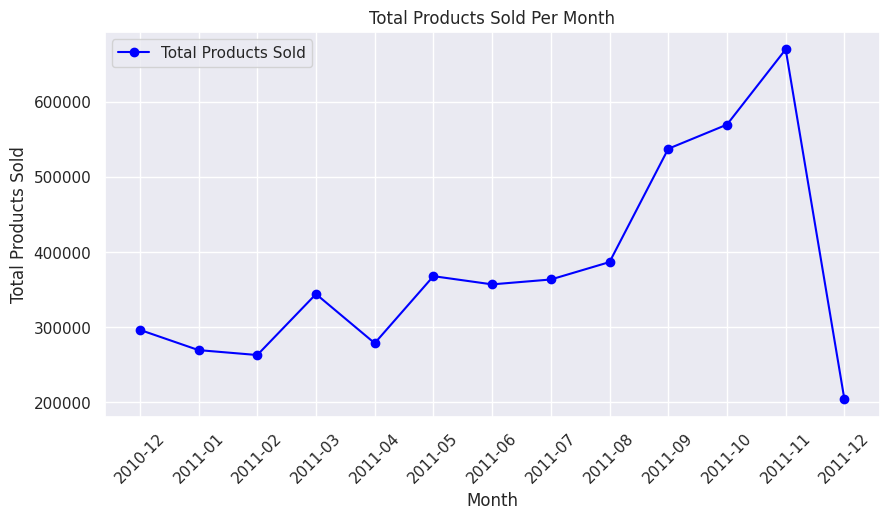

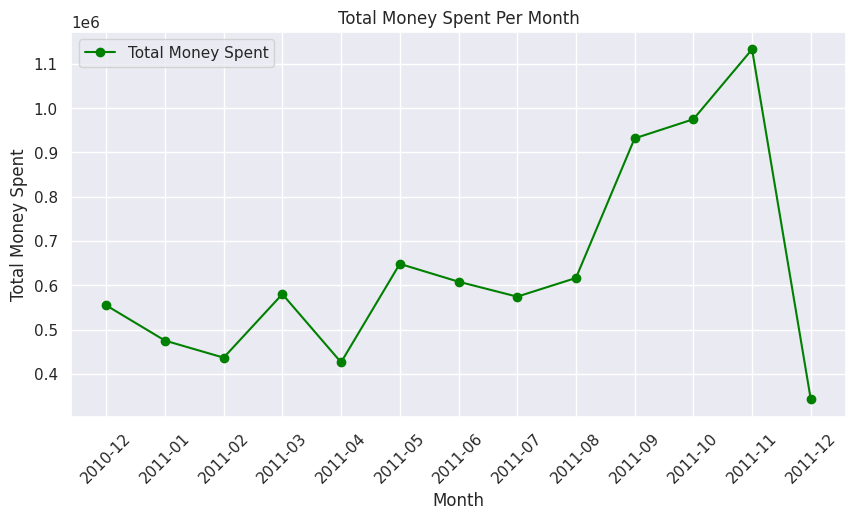

In [ ]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Extract the year and month from the 'InvoiceDate'
data['YearMonth'] = data['InvoiceDate'].dt.to_period('M')  # Creates 'YYYY-MM' format

# Calculate how many products are sold every month
products_sold_per_month = data.groupby('YearMonth')['Quantity'].sum().reset_index()
products_sold_per_month.columns = ['Month', 'Total Products Sold']

# Calculate how much customers spend every month
spending_per_month = data.groupby('YearMonth')['TotalPrice'].sum().reset_index()
spending_per_month.columns = ['Month', 'Total Money Spent']

# Plot the number of products sold per month (line plot)
plt.figure(figsize=(10, 5))
plt.plot(products_sold_per_month['Month'].astype(str), products_sold_per_month['Total Products Sold'], marker='o', color='blue', label='Total Products Sold')
plt.title('Total Products Sold Per Month')
plt.xlabel('Month')
plt.ylabel('Total Products Sold')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# Plot the total money spent per month (line plot)
plt.figure(figsize=(10, 5))
plt.plot(spending_per_month['Month'].astype(str), spending_per_month['Total Money Spent'], marker='o', color='green', label='Total Money Spent')
plt.title('Total Money Spent Per Month')
plt.xlabel('Month')
plt.ylabel('Total Money Spent')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#RFM Analysis

#Calculating Recency
data_recency = data.groupby(by='CustomerID',
                        as_index=False)['InvoiceDate'].max()
data_recency.columns = ['CustomerID', 'LastInvoiceDate']
recent_date = data_recency['LastInvoiceDate'].max()
data_recency['Recency'] = data_recency['LastInvoiceDate'].apply(
    lambda x: (recent_date - x).days)
print(data_recency.head(5))


   CustomerID     LastInvoiceDate  Recency
0     12346.0 2011-01-18 10:17:00      325
1     12347.0 2011-12-07 15:52:00        1
2     12348.0 2011-09-25 13:13:00       74
3     12349.0 2011-11-21 09:51:00       18
4     12350.0 2011-02-02 16:01:00      309


In [ ]:
#Calculating Frequency
frequency_data = data.drop_duplicates().groupby(
    by=['CustomerID'], as_index=False)['InvoiceDate'].count()
frequency_data.columns = ['CustomerID', 'Frequency']
frequency_data.head(5)


,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [ ]:
#Calculating Monetary Value
data['Total'] = data['UnitPrice']*data['Quantity']
monetary_data = data.groupby(by='CustomerID', as_index=False)['Total'].sum()
monetary_data.columns = ['CustomerID', 'Monetary']
monetary_data.head(5)

,CustomerID,Monetary
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [ ]:
#Merging RFM
rf_data = data_recency.merge(frequency_data, on='CustomerID')
rfm_data = rf_data.merge(monetary_data, on='CustomerID').drop(
    columns='LastInvoiceDate')
rfm_data.head(5)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,0.00
1,12347.0,1,182,4310.00
2,12348.0,74,31,1797.24
3,12349.0,18,73,1757.55
4,12350.0,309,17,334.40


In [ ]:
#Ranking Customer’s based upon their RFM score
rfm_data['R_rank'] = rfm_data['Recency'].rank(ascending=False)
rfm_data['F_rank'] = rfm_data['Frequency'].rank(ascending=True)
rfm_data['M_rank'] = rfm_data['Monetary'].rank(ascending=True)

In [ ]:
# normalizing the rank of the customers
rfm_data['R_rank_norm'] = (rfm_data['R_rank']/rfm_data['R_rank'].max())*100
rfm_data['F_rank_norm'] = (rfm_data['F_rank']/rfm_data['F_rank'].max())*100
rfm_data['M_rank_norm'] = (rfm_data['F_rank']/rfm_data['M_rank'].max())*100

rfm_data.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)
rfm_data.head(5)

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,12346.0,325,2,0.00,3.865741,2.493138,2.493138
1,12347.0,1,182,4310.00,97.719907,88.129003,88.129003
2,12348.0,74,31,1797.24,38.182870,42.074565,42.074565
3,12349.0,18,73,1757.55,72.974537,66.720037,66.720037
4,12350.0,309,17,334.40,5.578704,24.794145,24.794145


In [ ]:
#Calculating RFM score
rfm_data['RFM_Score'] = 0.15*rfm_data['R_rank_norm']+0.28 * \
    rfm_data['F_rank_norm']+0.57*rfm_data['M_rank_norm']
rfm_data['RFM_Score'] *= 0.05
rfm_data = rfm_data.round(2)
rfm_data[['CustomerID', 'RFM_Score']].head(5)

,CustomerID,RFM_Score
0,12346.0,0.13
1,12347.0,4.48
2,12348.0,2.07
3,12349.0,3.38
4,12350.0,1.10


In [ ]:
#Rating Customer based upon the RFM score
rfm_data["Customer_segment"] = np.where(rfm_data['RFM_Score'] >
                                      4.5, "Top Customers",
                                      (np.where(
                                        rfm_data['RFM_Score'] > 4,
                                        "High value Customer",
                                        (np.where(
    rfm_data['RFM_Score'] > 3,
                             "Medium Value Customer",
                             np.where(rfm_data['RFM_Score'] > 1.6,
                            'Low Value Customers', 'Lost Customers'))))))
rfm_data['CustomerID'] = rfm_data['CustomerID'].astype(int)
rfm_data[['CustomerID', 'RFM_Score', 'Customer_segment']].head(20)

,CustomerID,RFM_Score,Customer_segment
0,12346,0.13,Lost Customers
1,12347,4.48,High value Customer
2,12348,2.07,Low Value Customers
3,12349,3.38,Medium Value Customer
4,12350,1.10,Lost Customers
5,12352,3.56,Medium Value Customer
6,12353,0.34,Lost Customers
7,12354,2.66,Low Value Customers
8,12355,0.93,Lost Customers
9,12356,3.09,Medium Value Customer


In [ ]:
def count_customers_by_segment(rfm_data):
    # Group by the 'Customer_segment' column and count the number of customers in each segment
    segment_counts = rfm_data['Customer_segment'].value_counts()

    # Convert the result to a DataFrame for better readability
    segment_counts_df = segment_counts.reset_index()
    segment_counts_df.columns = ['Customer Segment', 'Number of Customers']

    return segment_counts_df
# Example usage:
segment_counts_df = count_customers_by_segment(rfm_data)
print(segment_counts_df)

        Customer Segment  Number of Customers
0         Lost Customers                 1339
1    Low Value Customers                 1335
2  Medium Value Customer                  927
3    High value Customer                  433
4          Top Customers                  338


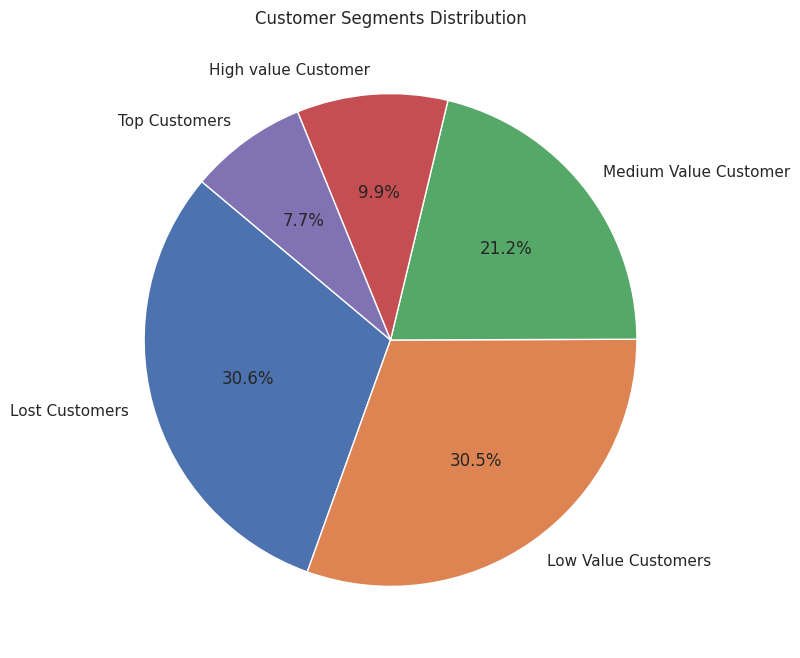

Top Customers:
Recommendation for 'Top Customers': Focus on increasing customer purchases. Form a cross/Up Selling Strategy.

High Value Customer:
Recommendation for 'High Value Customer': Optimize budget campaign and time campaign to maintain loyalty and increase value.

Medium Value Customer:
Recommendation for 'Medium Value Customer': Focus on reactivation and retention strategies to enhance engagement and spending.

Low Value Customers:
Recommendation for 'Low Value Customers': This customer segment has churned, so the focus is on reactivating the customer by forming a Reactivation strategy.

Lost Customers:
Recommendation for 'Lost Customers': The business team must focus on reactivating these customers, using targeted re-engagement campaigns.



In [ ]:
# Visualizing the customer segments with a pie chart (adjusted for new segments)
plt.figure(figsize=(8, 8))
plt.pie(rfm_data['Customer_segment'].value_counts(),
        labels=rfm_data['Customer_segment'].value_counts().index,
        autopct='%1.1f%%', startangle=140)
plt.title('Customer Segments Distribution')
plt.show()

# Define the recommendations for each customer segment
recommendations = {
    "Top Customers": "Recommendation for 'Top Customers': Focus on increasing customer purchases. "
                      "Form a cross/Up Selling Strategy.",

    "High Value Customer": "Recommendation for 'High Value Customer': Optimize budget campaign and time campaign "
                            "to maintain loyalty and increase value.",

    "Medium Value Customer": "Recommendation for 'Medium Value Customer': Focus on reactivation and retention strategies "
                             "to enhance engagement and spending.",

    "Low Value Customers": "Recommendation for 'Low Value Customers': This customer segment has churned, so the focus "
                            "is on reactivating the customer by forming a Reactivation strategy.",

    "Lost Customers": "Recommendation for 'Lost Customers': The business team must focus on reactivating these customers, "
                      "using targeted re-engagement campaigns."
}

# Display recommendations for each segment
for segment, recommendation in recommendations.items():
    print(f"{segment}:\n{recommendation}\n")

In [ ]:

X = df['InvoiceCounts']
y= df['InvoicePrice']

In [ ]:
#Split the data Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, train_size = 0.80)

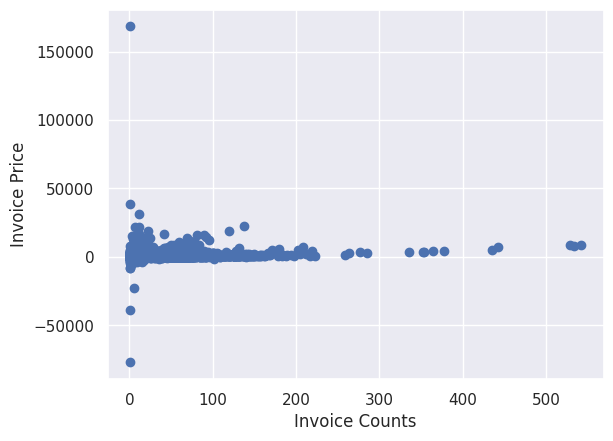

In [ ]:
#Plot of Train Data
plt.scatter(X_train, y_train)
plt.xlabel('Invoice Counts')
plt.ylabel('Invoice Price')
plt.show()

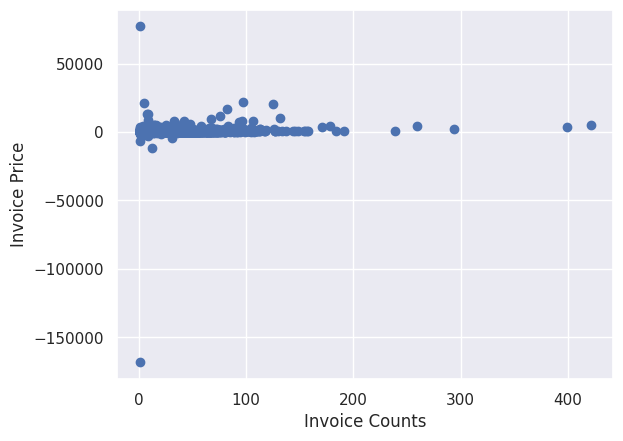

In [ ]:
#Plot of Test Data
plt.scatter(X_test, y_test)
plt.xlabel('Invoice Counts')
plt.ylabel('Invoice Price')
plt.show()

In [ ]:
#Elbow method to visualize the intertia
data_train = list(zip(X_train, y_train))
data_test = list(zip(X_test, y_test))
inertias = []

In [ ]:
for i in range(2,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data_train)
    inertias.append(kmeans.inertia_)

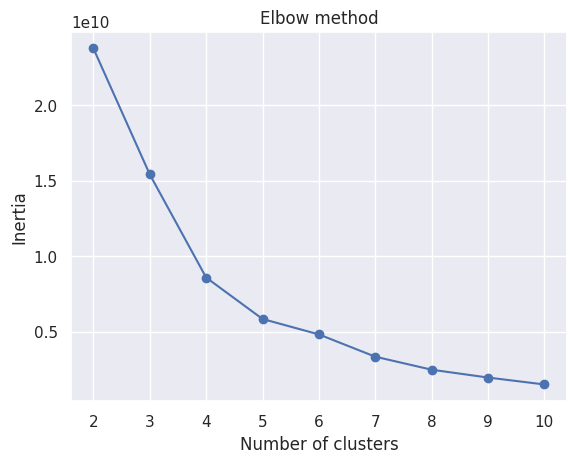

In [ ]:
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
#K-Means model with three clusters
#define our scaler
scaler = MinMaxScaler()
# scale down our data
data_scaled_train = scaler.fit_transform(data_train)
data_scaled_test = scaler.fit_transform(data_test)


In [ ]:
print( data_scaled_train[0:4])
print(data_scaled_test[0:4])

[[0.00184843 0.31547482]
 [0.04436229 0.31590633]
 [0.04251386 0.31666597]
 [0.0702403  0.31741125]]
[[0.         0.68739019]
 [0.00714286 0.68843052]
 [0.02857143 0.68677713]
 [0.0452381  0.68741775]]



 kmeans.cluster_centers are :
[[0.01330952 0.31530756]
 [0.06774177 0.31661095]
 [0.19818569 0.31919394]]

 kmeans.inertia_ is :
10.73167682104145


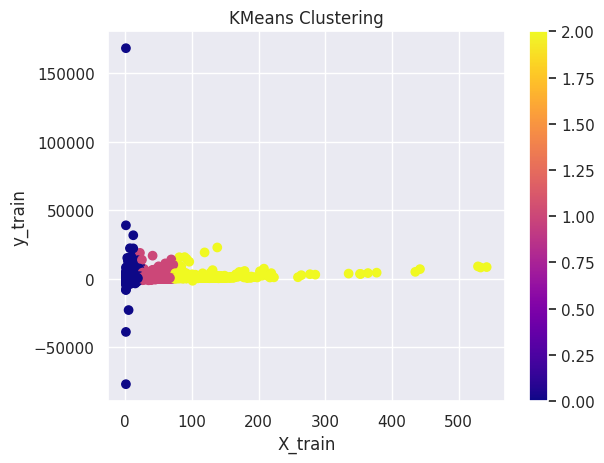

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(data_scaled_train)

print('\n kmeans.cluster_centers are :')
print(kmeans.cluster_centers_)
print('\n kmeans.inertia_ is :')
print(kmeans.inertia_)

# Scatter plot with changed colors using colormap (e.g., 'viridis', 'plasma', 'coolwarm', etc.)
plt.scatter(X_train, y_train, c=kmeans.labels_, cmap='plasma')  # Change 'plasma' to other colormaps if desired
plt.title('KMeans Clustering')
plt.xlabel('X_train')
plt.ylabel('y_train')
plt.colorbar()  # Shows the color legend
plt.show()

In [ ]:
#Checking quality of classification by the K-Means model
labels = kmeans.labels_

In [ ]:
# check how many of the samples were correctly labeled
correct_labels = sum(labels)
print("\n Result: %d out of %d samples are correctly labeled." % (correct_labels, y.size))
print('\n Accuracy score due to K-Means Model: {0:0.2f}'. format(correct_labels/float(y.size)))


 Result: 5327 out of 22190 samples are correctly labeled.

 Accuracy score due to K-Means Model: 0.24


In [ ]:
#Evaluating performance of the clustering algorithm using a Silhouette score
print('\n The Silhouette score for K-Means is : ')
print(silhouette_score(data_scaled_train, kmeans.labels_, metric='euclidean'))


 The Silhouette score for K-Means is : 
0.6350166413336015


In [ ]:
#Gaussian Mixture Model

# Standardize data
scaler = StandardScaler()
scaled_df = scaler.fit_transform(data_train)

In [ ]:
# Normalizing the Data
normalized_df = normalize(scaled_df)

In [ ]:
# Converting the numpy array into a pandas DataFrame
normalized_df = pd.DataFrame(normalized_df)

In [ ]:
# Reducing the dimensions of the data
pca = PCA(n_components = 2)
X_principal = pca.fit_transform(normalized_df)
X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']
X_principal.head(3)

,P1,P2
0,-0.700913,0.184046
1,1.291005,0.007091
2,1.233905,0.420789


In [ ]:
gmm = GaussianMixture(n_components=3)
gmm.fit(scaled_df)

GaussianMixture(n_components=3)

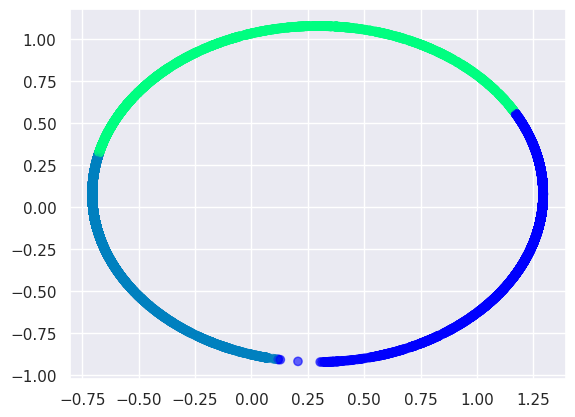

In [ ]:
#Visualizing the clustering of GaussianMixture
plt.scatter(X_principal['P1'], X_principal['P2'],
           c = GaussianMixture(n_components = 3).fit_predict(X_principal), cmap =plt.cm.winter, alpha = 0.6)
plt.show()

In [ ]:
# Checking quality of classification by the Gaussian Mixture model
labels = gmm.predict(scaled_df)
correct_labels = sum(labels)
print("Result: %d out of %d samples are correctly labeled." % (correct_labels, y.size))
print('\n Accuracy score due to Gaussian Mixture Model: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 13646 out of 22190 samples are correctly labeled.

 Accuracy score due to Gaussian Mixture Model: 0.61


In [ ]:
#DBSCAN Clustering Model (Distribution Based)

#create a ‘Cluster’ column
# Generate sample data
centers = [[1, 1], [-1, -1], [1, -1]]
data_train, labels_true = make_blobs(n_samples=750, centers=centers, cluster_std=0.4, random_state=0)
X = StandardScaler().fit_transform(data_train)

In [ ]:
#Computing DB_SCAN
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

In [ ]:
#Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

In [ ]:
#Evaluation of DB_SCAN
#Silhouette Coefficient score of more than 0.5 indicating that my model # doesn’t have overlapping clusters or mislabeled data points.
print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)
print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels_true, labels))
print("Completeness: %0.3f" % metrics.completeness_score(labels_true, labels))
print("V-measure: %0.3f" % metrics.v_measure_score(labels_true, labels))
print("Adjusted Rand Index: %0.3f"
      % metrics.adjusted_rand_score(labels_true, labels))
print("Adjusted Mutual Information: %0.3f"
      % metrics.adjusted_mutual_info_score(labels_true, labels))
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(X, labels))

Estimated number of clusters: 3
Estimated number of noise points: 18
Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


In [ ]:
#Visualizing the clustering
# Plot result
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

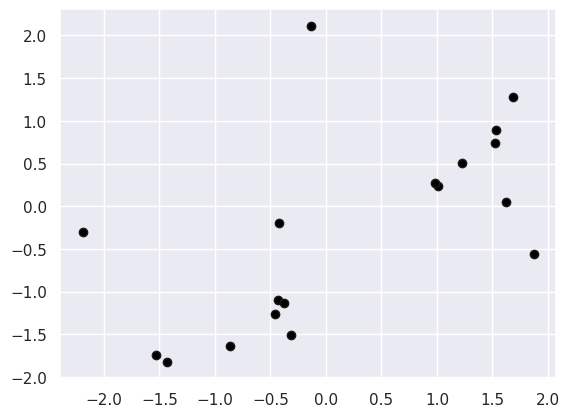

In [ ]:
    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)


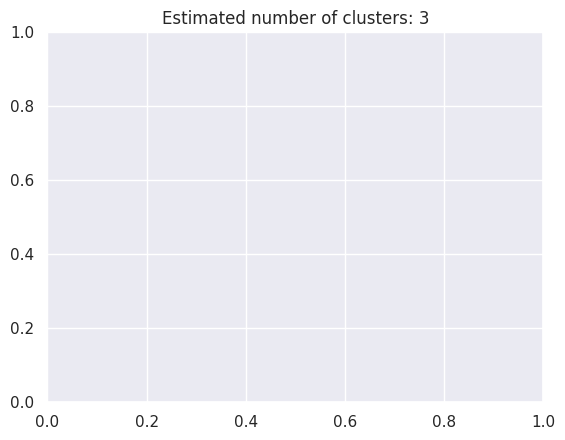

In [ ]:
plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.show()

In [ ]:
# #Hierarchical Clustering
# #Dendogram Construction
# plt.figure(figsize=(10, 7))
# plt.title("DENDOGRAM FOR  DATASET")
# dendo_gram = shc.dendrogram(shc.linkage(X, method = "ward"))


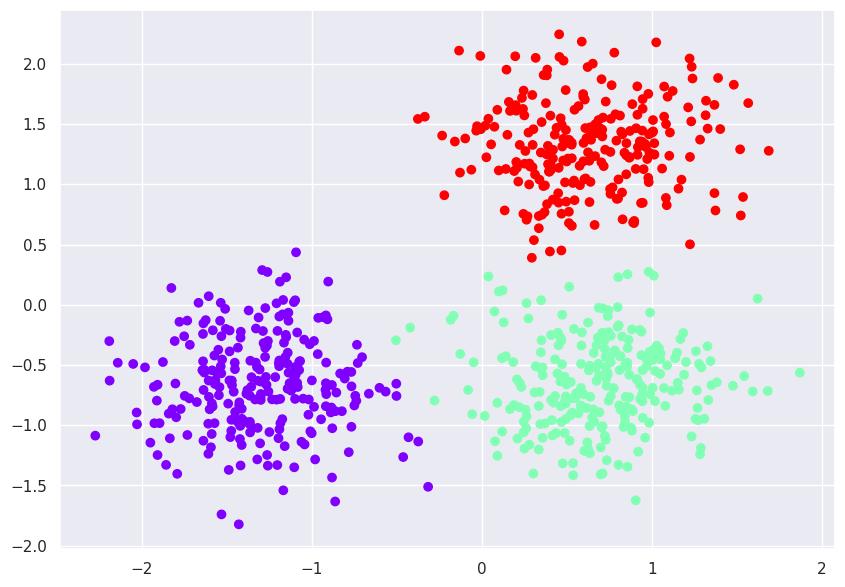

In [ ]:
#Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters = 3, metric = "euclidean", linkage = "ward")
cluster.fit_predict(X)
#Visualising the clusters
plt.figure(figsize=(10, 7))
plt.scatter(X[:,0], X[:,1], c=cluster.labels_, cmap='rainbow')

In [ ]:
#Computing Agglomerative Score
print('Agglomerative Score is :')
print(silhouette_score(X,cluster.labels_, metric='euclidean'))

Agglomerative Score is :
0.6477977039854915


Clusters of Birch [0 1 2]


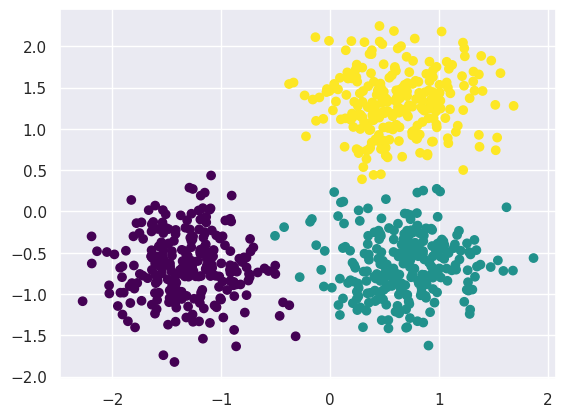

Score of Birch =  0.6472104406200997


In [ ]:
#BIRCH Algorithm
model_br = Birch(threshold=0.01, n_clusters=3)
model_br.fit(X)
yhat_br = model_br.predict(X)
clusters_br = unique(yhat_br)
print("Clusters of Birch",clusters_br)
labels_br = model_br.labels_
plt.scatter(X[:,0], X[:,1], c=cluster.labels_, cmap='viridis')
plt.show()
score_br = metrics.silhouette_score(X,labels_br)
print("Score of Birch = ", score_br)

In [ ]:
# Assuming your data is already scaled
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # X is your feature matrix (e.g., RFM data)

# Function to calculate Silhouette Score and time taken for each algorithm
def calculate_clustering_performance(X_scaled):
    # Dictionary to store results
    results = {
        'Algorithm': [],
        'Silhouette Score': [],
        'Time Taken (seconds)': [],
        'Number of Clusters': [],
    }

    # KMeans Clustering
    start_time = time.time()
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels) if len(set(kmeans_labels)) > 1 else np.nan
    kmeans_time = time.time() - start_time
    kmeans_clusters = len(set(kmeans_labels))

    # Store KMeans results
    results['Algorithm'].append('KMeans')
    results['Silhouette Score'].append(kmeans_silhouette)
    results['Time Taken (seconds)'].append(kmeans_time)
    results['Number of Clusters'].append(kmeans_clusters)

    # DBSCAN Clustering
    start_time = time.time()
    dbscan = DBSCAN(eps=0.12, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    # Exclude noise points (-1) for Silhouette Score calculation
    non_noise_points = X_scaled[dbscan_labels != -1]
    non_noise_labels = dbscan_labels[dbscan_labels != -1]

    if len(set(non_noise_labels)) > 1:
        dbscan_silhouette = silhouette_score(non_noise_points, non_noise_labels)
    else:
        dbscan_silhouette = np.nan  # Not enough clusters to compute silhouette score

    dbscan_time = time.time() - start_time
    dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

    # Store DBSCAN results
    results['Algorithm'].append('DBSCAN')
    results['Silhouette Score'].append(dbscan_silhouette)
    results['Time Taken (seconds)'].append(dbscan_time)
    results['Number of Clusters'].append(dbscan_clusters)

    # Gaussian Mixture Clustering
    start_time = time.time()
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_silhouette = silhouette_score(X_scaled, gmm_labels) if len(set(gmm_labels)) > 1 else np.nan
    gmm_time = time.time() - start_time
    gmm_clusters = len(set(gmm_labels))

    # Store Gaussian Mixture results
    results['Algorithm'].append('Gaussian Mixture')
    results['Silhouette Score'].append(gmm_silhouette)
    results['Time Taken (seconds)'].append(gmm_time)
    results['Number of Clusters'].append(gmm_clusters)


    # Return results as a DataFrame
    return pd.DataFrame(results)

# Call the function and display the results
clustering_results = calculate_clustering_performance(X_scaled)
print(clustering_results)

# Display results in a table format (for example in Jupyter/Colab)
from IPython.display import display
display(clustering_results)

          Algorithm  Silhouette Score  Time Taken (seconds)  \
0            KMeans          0.649604              0.016145   
1            DBSCAN               NaN              0.011068   
2  Gaussian Mixture          0.649649              0.023110   

   Number of Clusters  
0                   3  
1                   1  
2                   3  


,Algorithm,Silhouette Score,Time Taken (seconds),Number of Clusters
0,KMeans,0.649604,0.016145,3
1,DBSCAN,NaN,0.011068,1
2,Gaussian Mixture,0.649649,0.023110,3


In [ ]:
# Assuming 'rfm_data' is the dataframe that contains the RFM scores and customer segments
def search_customer_by_id(customer_id, rfm_data):
    customer_row = rfm_data[rfm_data['CustomerID'] == customer_id]
    if not customer_row.empty:
        customer_segment = customer_row['Customer_segment'].values[0]
        return f"Customer ID {customer_id} belongs to the '{customer_segment}' segment."
    else:
        return f"Customer ID {customer_id} not found."
customer_id_input = input("Enter Customer ID (5 digits): ")
if customer_id_input.isdigit() and len(customer_id_input) == 5:
    customer_id_input = int(customer_id_input)
    result = search_customer_by_id(customer_id_input, rfm_data)
    print(result)
else:
    print("Invalid Customer ID. Please enter a 5-digit number.")

Enter Customer ID (5 digits): 12457
Customer ID 12457 belongs to the 'Medium Value Customer' segment.
